In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.datasets import make_classification
X , y = make_classification(
    n_samples = 100 , n_features = 2, n_informative = 1 , n_redundant = 0, 
    n_classes = 2 , n_clusters_per_class = 1 , random_state = 41 , hypercube = False , class_sep = 10 
)

In [3]:
X.shape

(100, 2)

In [8]:
X 

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [9]:
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

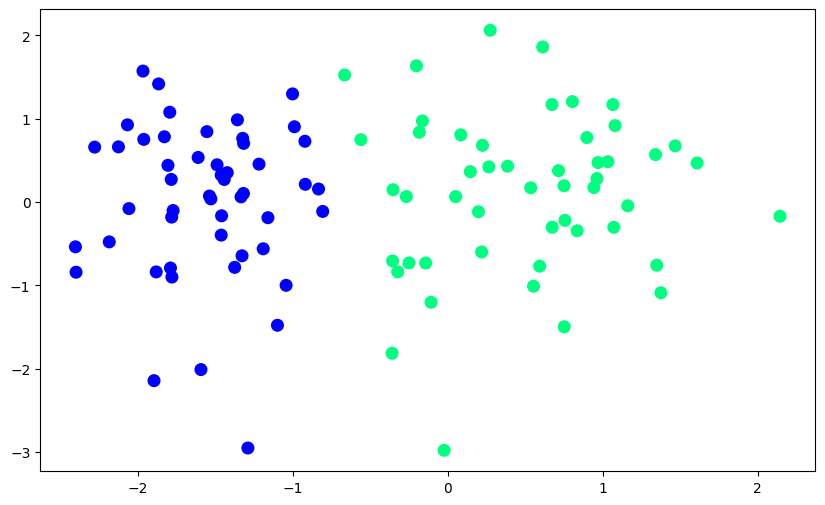

In [6]:
plt.figure(figsize = (10 , 6))
plt.scatter(X[: , 0] , X[: , 1] , c = y , cmap = 'winter' , s = 70)
plt.show()

<h3 style = "color : red">Note: </h3>
 Here X and Y is our 2 feature and based on that we have blue and green 2 classes.<br> 
 And Green is the +ve class(1) <br>
 Blue is the -ve class(0)

In [20]:
def perceptron(X , y): 
    # Insert X0 column as 1(first we insert a 1 column at the first position)
    X = np.insert(X , 0 , 1 , axis = 1)
    weights = np.ones(X.shape[1]) # initalize weights with random value here we are doing 1
    learning_rate = 0.1
    epochs = 1000
    total_rows = X.shape[0]
    
    for epoch in range(epochs): 
        j = np.random.randint(0 , total_rows) # randomly selecting a row
        y_pred = step(np.dot(X[j] , weights)) # find the prediction
        weights = weights + learning_rate * (y[j] - y_pred) * X[j] # update the weights

    return weights[0] , weights[1 : ]

In [13]:
def step(z): 
    return 1 if z > 0 else 0

In [15]:
random_index = 21
random_row = X[random_index]
random_row

array([-2.06519502,  0.92649819])

In [16]:
np.insert(random_row , 0 , 1)

array([ 1.        , -2.06519502,  0.92649819])

In [21]:
intercept_ , coef_ = perceptron(X , y) 

In [22]:
print(coef_)
print(intercept_)

[1.31270117 0.07035254]
0.9


In [23]:
''' 
Ax + By + c = 0
y = (-A/B)x + (-c/b)
'''
slope = - coef_[0] / coef_[1]
c = -intercept_ / coef_[1]

In [25]:
x_input = np.linspace(-3 , 3 , 100)
y_input = slope * x_input + c 

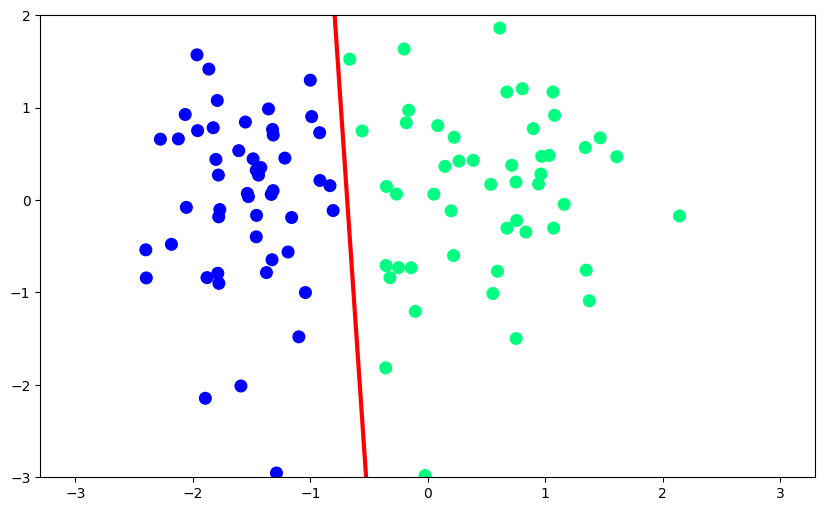

In [28]:
plt.figure(figsize = (10 , 6))
plt.scatter(X[: , 0] , X[: , 1] , c = y , cmap = 'winter' , s = 70)

# plot the line 
plt.plot(x_input , y_input , color = 'red' , linewidth = 3)
plt.ylim(-3 , 2)
plt.show()